In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import datetime
import statsmodels.graphics.tsaplots
from statsmodels.tsa.stattools import adfuller
from sklearn.model_selection import TimeSeriesSplit
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
import statistics

In [4]:
data = pd.read_csv('Data/preprocessed/NP15_da_series.csv')
data['begin_time'] = pd.to_datetime(data['begin_time'])

We first take about 80% of the data from the start as training data.

In [5]:
data_train=data.iloc[:35000]
data_train

,begin_time,NP-15 LMP,NP-15 LMP 24hrdiffs
0,2020-01-01 00:00:00,32.76137,NaN
1,2020-01-01 01:00:00,30.90384,NaN
2,2020-01-01 02:00:00,32.15974,NaN
3,2020-01-01 03:00:00,31.24182,NaN
4,2020-01-01 04:00:00,30.98365,NaN
...,...,...,...
34995,2023-12-29 03:00:00,40.07050,-1.49214
34996,2023-12-29 04:00:00,40.45272,-4.22563
34997,2023-12-29 05:00:00,46.68461,-3.02693
34998,2023-12-29 06:00:00,48.25084,-2.38759


We aim to perform cross validation for various models across time series splits. We customise cross validation to get validation for a variety of days (i.e. not all of them should be in December).

In [55]:
# Get data between specified dates
def filter_times(df, time1, time2):
    return df.apply(lambda x: (time1 <= x['begin_time']) and (x['begin_time'] <= time2) , axis=1)

In [64]:
def crossValidate(start_year, end_year, n_splits, test_size, seas_order, non_seas_order):
    ts_split = TimeSeriesSplit(n_splits=n_splits, test_size=test_size)
    mse_list = []

    print(f"Seasonal order - {seas_order}, Non-seasonal order - {non_seas_order}")

    for j in range(1,7):
        time2 = datetime.datetime(end_year, 1, 1, 0, 0, 0)+datetime.timedelta(days=60*j)
        df = data_train[filter_times(data_train, datetime.datetime(start_year, 1, 1, 0, 0, 0), time2)].copy().reset_index(drop=True)    
        for i, (train_index, test_index) in enumerate(ts_split.split(df)):
            if (end_year==2023) and (j==4):
                continue
            if (end_year==2022) and (j==3):
                continue
            model = SARIMAX(endog=df['NP-15 LMP'].loc[train_index], order=non_seas_order, seasonal_order=seas_order)
            model_fit = model.fit()
            #print(model_fit.summary())
            mse = mean_squared_error(df['NP-15 LMP'].loc[test_index], model_fit.forecast(test_size))
            mse_list.append(mse)
            print(f"mse for validation in {time2}, fold {i} = {mse} ")
            #data_predicted = data_train.join(pd.concat([data_train['NP-15 LMP'].loc[train_index].tail(test_size), model_fit.forecast(test_size)]).to_frame(name='predicted'), how='inner')
            #plt.figure(figsize=(18, 4))
            #plt.plot(data_predicted['begin_time'], data_predicted['NP-15 LMP'] , label='Actual')
            #plt.plot(data_predicted['begin_time'], data_predicted['predicted'] , label='Predicted')
            #plt.xticks(rotation=90)
            #plt.legend()
            #plt.show()
    
    print(f"Validation error when starting from {start_year} for {end_year} = {statistics.fmean(mse_list)}")

In [59]:
crossValidate(2022, 2023, 3, 72, (0,1,0, 24), (0,0,0))

Seasonal order - (0, 1, 0, 24), Non-seasonal order - (0, 0, 0)
mse for validation in 2023-03-02 00:00:00, fold 0 = 955.0793155754473 
mse for validation in 2023-03-02 00:00:00, fold 1 = 1229.0399513178959 
mse for validation in 2023-03-02 00:00:00, fold 2 = 489.1793912782597 
mse for validation in 2023-05-01 00:00:00, fold 0 = 430.60499282893056 
mse for validation in 2023-05-01 00:00:00, fold 1 = 783.7398156190943 
mse for validation in 2023-05-01 00:00:00, fold 2 = 1256.1951870917194 
mse for validation in 2023-06-30 00:00:00, fold 0 = 150.32058235679307 
mse for validation in 2023-06-30 00:00:00, fold 1 = 160.08963907312082 
mse for validation in 2023-06-30 00:00:00, fold 2 = 61.20584997034723 
mse for validation in 2023-10-28 00:00:00, fold 0 = 979.8056095147141 
mse for validation in 2023-10-28 00:00:00, fold 1 = 69.34717323137914 
mse for validation in 2023-10-28 00:00:00, fold 2 = 23.794252403627784 
mse for validation in 2023-12-27 00:00:00, fold 0 = 47.40465127082777 
mse for 

In [60]:
crossValidate(2023, 2023, 3, 72, (0,1,0, 24), (0,0,0))

Seasonal order - (0, 1, 0, 24), Non-seasonal order - (0, 0, 0)
mse for validation in 2023-03-02 00:00:00, fold 0 = 955.0793155754473 
mse for validation in 2023-03-02 00:00:00, fold 1 = 1229.0399513178959 
mse for validation in 2023-03-02 00:00:00, fold 2 = 489.1793912782598 
mse for validation in 2023-05-01 00:00:00, fold 0 = 430.60499282893056 
mse for validation in 2023-05-01 00:00:00, fold 1 = 783.7398156190943 
mse for validation in 2023-05-01 00:00:00, fold 2 = 1256.1951870917194 
mse for validation in 2023-06-30 00:00:00, fold 0 = 150.32058235679307 
mse for validation in 2023-06-30 00:00:00, fold 1 = 160.08963907312082 
mse for validation in 2023-06-30 00:00:00, fold 2 = 61.20584997034723 
mse for validation in 2023-10-28 00:00:00, fold 0 = 979.8056095147141 
mse for validation in 2023-10-28 00:00:00, fold 1 = 69.34717323137919 
mse for validation in 2023-10-28 00:00:00, fold 2 = 23.794252403627784 
mse for validation in 2023-12-27 00:00:00, fold 0 = 47.40465127082777 
mse for 

In [61]:
crossValidate(2023, 2023, 3, 72, (1,1,1, 24), (0,0,0))

Seasonal order - (1, 1, 1, 24), Non-seasonal order - (0, 0, 0)
mse for validation in 2023-03-02 00:00:00, fold 0 = 741.5006387637043 
mse for validation in 2023-03-02 00:00:00, fold 1 = 2093.11852978345 
mse for validation in 2023-03-02 00:00:00, fold 2 = 390.9389493044021 
mse for validation in 2023-05-01 00:00:00, fold 0 = 375.66324884951297 
mse for validation in 2023-05-01 00:00:00, fold 1 = 599.6766170306109 
mse for validation in 2023-05-01 00:00:00, fold 2 = 697.0186405575145 
mse for validation in 2023-06-30 00:00:00, fold 0 = 101.55373531305725 
mse for validation in 2023-06-30 00:00:00, fold 1 = 103.1793950721943 
mse for validation in 2023-06-30 00:00:00, fold 2 = 87.96754280139739 
mse for validation in 2023-10-28 00:00:00, fold 0 = 747.3249775504653 
mse for validation in 2023-10-28 00:00:00, fold 1 = 124.79807659497864 
mse for validation in 2023-10-28 00:00:00, fold 2 = 54.40867200450058 
mse for validation in 2023-12-27 00:00:00, fold 0 = 46.058999132952735 
mse for val

In [62]:
crossValidate(2022, 2023, 3, 72, (1,1,1, 24), (0,0,0))

Seasonal order - (1, 1, 1, 24), Non-seasonal order - (0, 0, 0)
mse for validation in 2023-03-02 00:00:00, fold 0 = 968.3690962308121 
mse for validation in 2023-03-02 00:00:00, fold 1 = 1249.9655675314577 
mse for validation in 2023-03-02 00:00:00, fold 2 = 488.6256721231656 
mse for validation in 2023-05-01 00:00:00, fold 0 = 429.7328338592769 
mse for validation in 2023-05-01 00:00:00, fold 1 = 804.5587735622489 
mse for validation in 2023-05-01 00:00:00, fold 2 = 1261.7908221273983 
mse for validation in 2023-06-30 00:00:00, fold 0 = 146.74663011700855 
mse for validation in 2023-06-30 00:00:00, fold 1 = 156.79672171366772 
mse for validation in 2023-06-30 00:00:00, fold 2 = 62.4390608950806 
mse for validation in 2023-10-28 00:00:00, fold 0 = 975.2650924048061 
mse for validation in 2023-10-28 00:00:00, fold 1 = 70.94030427526205 
mse for validation in 2023-10-28 00:00:00, fold 2 = 25.889124336645466 
mse for validation in 2023-12-27 00:00:00, fold 0 = 48.7382163774833 
mse for val

In [65]:
crossValidate(2022, 2022, 3, 72, (1,1,1, 24), (0,0,0))

Seasonal order - (1, 1, 1, 24), Non-seasonal order - (0, 0, 0)
mse for validation in 2022-03-02 00:00:00, fold 0 = 216.07818198161775 
mse for validation in 2022-03-02 00:00:00, fold 1 = 120.11658176098834 
mse for validation in 2022-03-02 00:00:00, fold 2 = 34.121853729940874 
mse for validation in 2022-05-01 00:00:00, fold 0 = 436.7602420114578 
mse for validation in 2022-05-01 00:00:00, fold 1 = 462.4450701819868 
mse for validation in 2022-05-01 00:00:00, fold 2 = 167.88668860630554 
mse for validation in 2022-08-29 00:00:00, fold 0 = 221.88716126819645 
mse for validation in 2022-08-29 00:00:00, fold 1 = 107.38389949907423 
mse for validation in 2022-08-29 00:00:00, fold 2 = 309.9278730231895 
mse for validation in 2022-10-28 00:00:00, fold 0 = 213.49450010604636 
mse for validation in 2022-10-28 00:00:00, fold 1 = 45.07172781887417 
mse for validation in 2022-10-28 00:00:00, fold 2 = 24.97500162412076 
mse for validation in 2022-12-27 00:00:00, fold 0 = 2004.9430125045822 
mse fo

In [66]:
crossValidate(2021, 2022, 3, 72, (1,1,1, 24), (0,0,0))

Seasonal order - (1, 1, 1, 24), Non-seasonal order - (0, 0, 0)
mse for validation in 2022-03-02 00:00:00, fold 0 = 99.81093780027072 
mse for validation in 2022-03-02 00:00:00, fold 1 = 101.22574233846288 
mse for validation in 2022-03-02 00:00:00, fold 2 = 37.25109994044577 
mse for validation in 2022-05-01 00:00:00, fold 0 = 407.9832196933442 
mse for validation in 2022-05-01 00:00:00, fold 1 = 606.1826579155812 
mse for validation in 2022-05-01 00:00:00, fold 2 = 148.1117027400552 
mse for validation in 2022-08-29 00:00:00, fold 0 = 112.1566621092678 
mse for validation in 2022-08-29 00:00:00, fold 1 = 209.0760699445454 
mse for validation in 2022-08-29 00:00:00, fold 2 = 202.90434852862472 
mse for validation in 2022-10-28 00:00:00, fold 0 = 200.94118352323233 
mse for validation in 2022-10-28 00:00:00, fold 1 = 44.41999356606686 
mse for validation in 2022-10-28 00:00:00, fold 2 = 23.917234911293704 
mse for validation in 2022-12-27 00:00:00, fold 0 = 1845.3679864577082 
mse for v

In [52]:
crossValidate(data_train_list, datetime.datetime(2023, 1, 1, 0, 0, 0), 3, 72, (1,1,1, 24), (0,0,0))

72.7318971493922
19.966179801475214
11.823168522136015
515.237198694243
58.108416741657166
53.7779712922397
89.06380111536139
103.19824083767651
96.06399062699549
342.8948611242598
280.86862968425504
291.7441052972717
91.04672709838354
3414.6817768067626
299.0523038035447
Validation error when starting from 2023-01-01 00:00:00 = 382.68395123971027


                                SARIMAX Results                                 
Dep. Variable:                NP-15 LMP   No. Observations:                34784
Model:             SARIMAX(1, 1, 0, 24)   Log Likelihood             -156690.389
Date:                  Wed, 16 Apr 2025   AIC                         313384.778
Time:                          14:24:15   BIC                         313401.690
Sample:                               0   HQIC                        313390.166
                                - 34784                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.S.L24      -0.1571      0.001   -294.289      0.000      -0.158      -0.156
sigma2       680.0560      0.473   1437.279      0.000     679.129     680.983
Ljung-Box (L1) (Q):               22

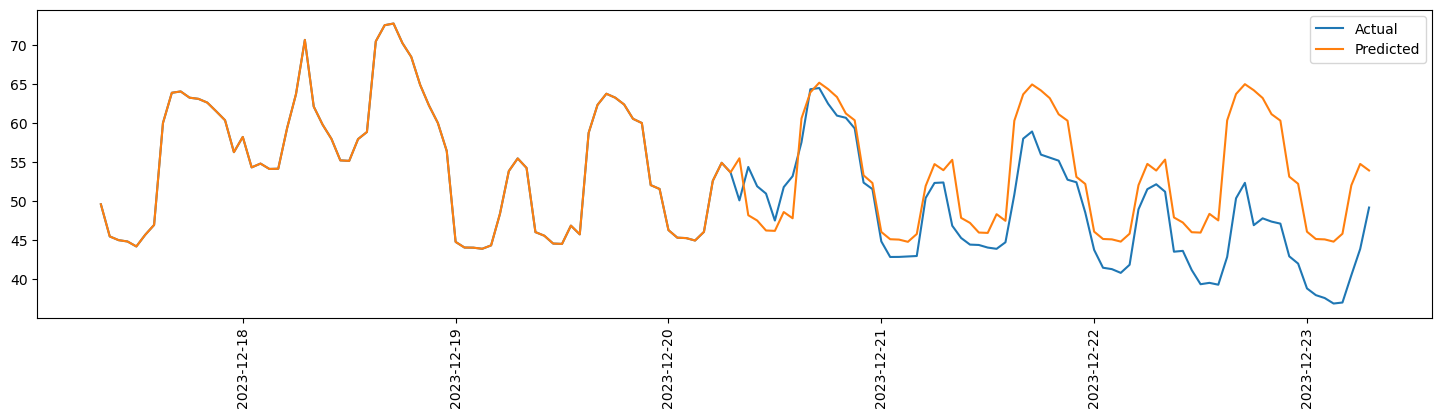

                                SARIMAX Results                                 
Dep. Variable:                NP-15 LMP   No. Observations:                34856
Model:             SARIMAX(1, 1, 0, 24)   Log Likelihood             -156992.641
Date:                  Wed, 16 Apr 2025   AIC                         313989.283
Time:                          14:25:31   BIC                         314006.199
Sample:                               0   HQIC                        313994.672
                                - 34856                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.S.L24      -0.1571      0.001   -294.872      0.000      -0.158      -0.156
sigma2       678.6495      0.471   1440.260      0.000     677.726     679.573
Ljung-Box (L1) (Q):               22

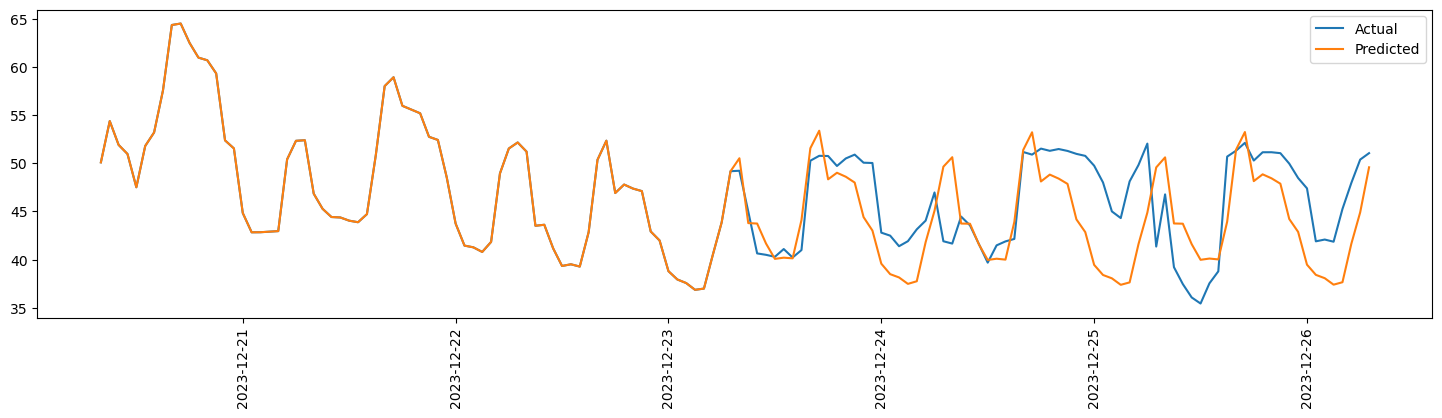

                                SARIMAX Results                                 
Dep. Variable:                NP-15 LMP   No. Observations:                34928
Model:             SARIMAX(1, 1, 0, 24)   Log Likelihood             -157294.212
Date:                  Wed, 16 Apr 2025   AIC                         314592.424
Time:                          14:26:49   BIC                         314609.345
Sample:                               0   HQIC                        314597.815
                                - 34928                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.S.L24      -0.1571      0.001   -295.492      0.000      -0.158      -0.156
sigma2       677.2245      0.469   1443.297      0.000     676.305     678.144
Ljung-Box (L1) (Q):               22

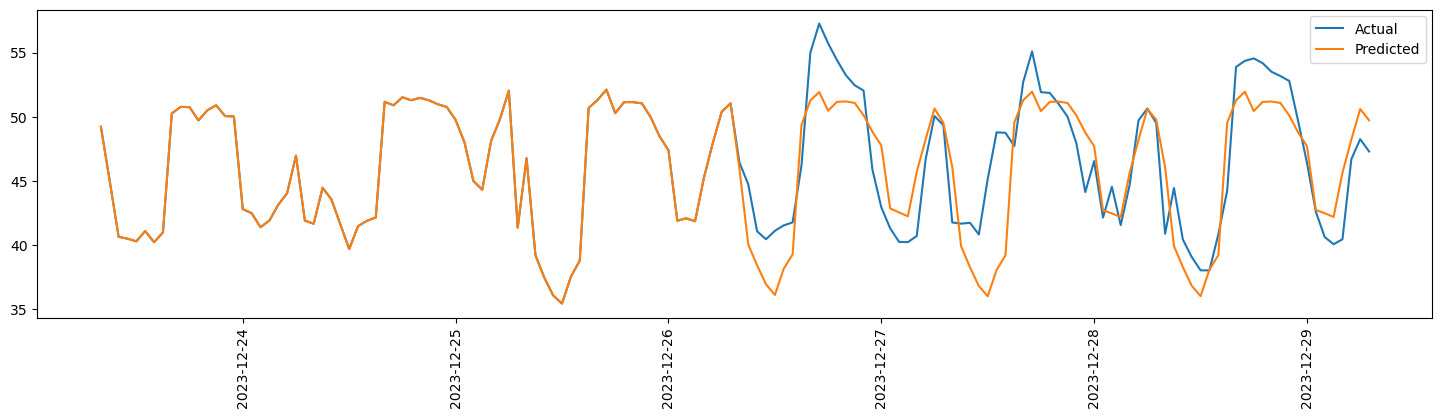

                                SARIMAX Results                                 
Dep. Variable:                NP-15 LMP   No. Observations:                33343
Model:             SARIMAX(1, 1, 0, 24)   Log Likelihood             -150638.614
Date:                  Wed, 16 Apr 2025   AIC                         301281.228
Time:                          14:27:56   BIC                         301298.056
Sample:                               0   HQIC                        301286.600
                                - 33343                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.S.L24      -0.1592      0.001   -287.602      0.000      -0.160      -0.158
sigma2       705.4126      0.509   1385.920      0.000     704.415     706.410
Ljung-Box (L1) (Q):               21

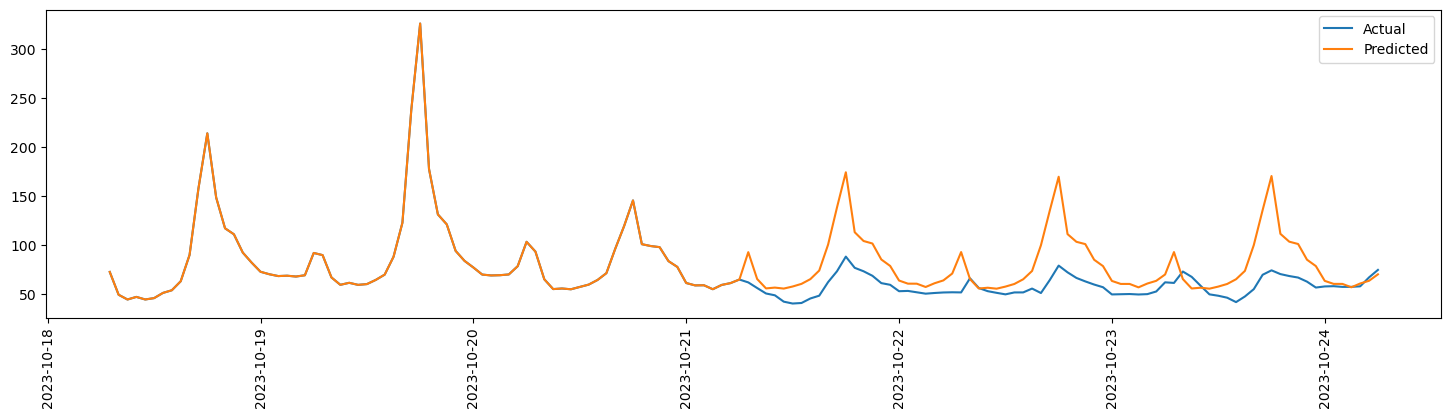

                                SARIMAX Results                                 
Dep. Variable:                NP-15 LMP   No. Observations:                33415
Model:             SARIMAX(1, 1, 0, 24)   Log Likelihood             -150958.153
Date:                  Wed, 16 Apr 2025   AIC                         301920.306
Time:                          14:28:43   BIC                         301937.138
Sample:                               0   HQIC                        301925.679
                                - 33415                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.S.L24      -0.1577      0.001   -285.123      0.000      -0.159      -0.157
sigma2       704.5859      0.508   1387.268      0.000     703.590     705.581
Ljung-Box (L1) (Q):               21

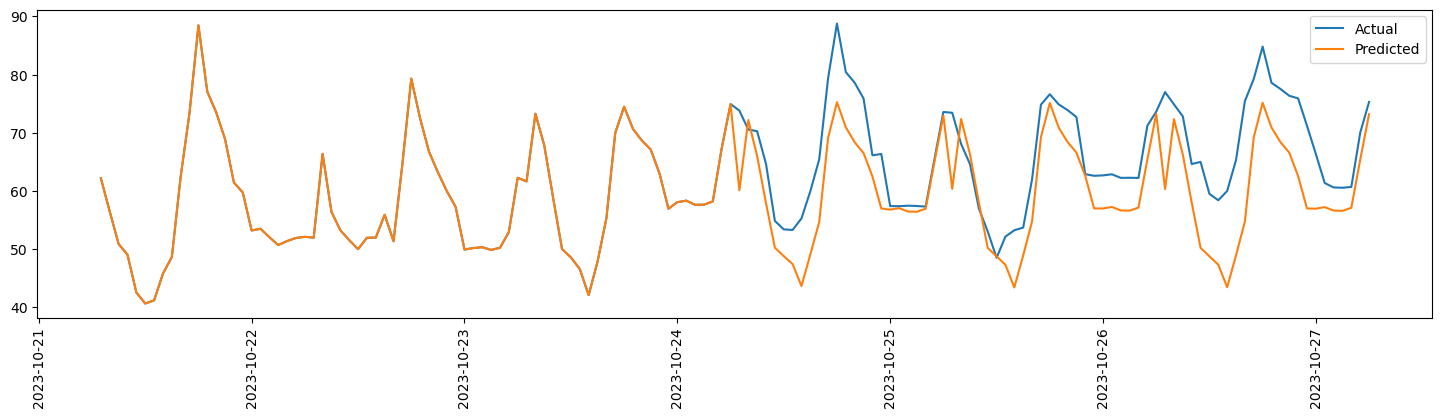

                                SARIMAX Results                                 
Dep. Variable:                NP-15 LMP   No. Observations:                33487
Model:             SARIMAX(1, 1, 0, 24)   Log Likelihood             -151262.394
Date:                  Wed, 16 Apr 2025   AIC                         302528.787
Time:                          14:29:39   BIC                         302545.623
Sample:                               0   HQIC                        302534.161
                                - 33487                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.S.L24      -0.1577      0.001   -285.789      0.000      -0.159      -0.157
sigma2       703.0992      0.506   1390.214      0.000     702.108     704.090
Ljung-Box (L1) (Q):               21

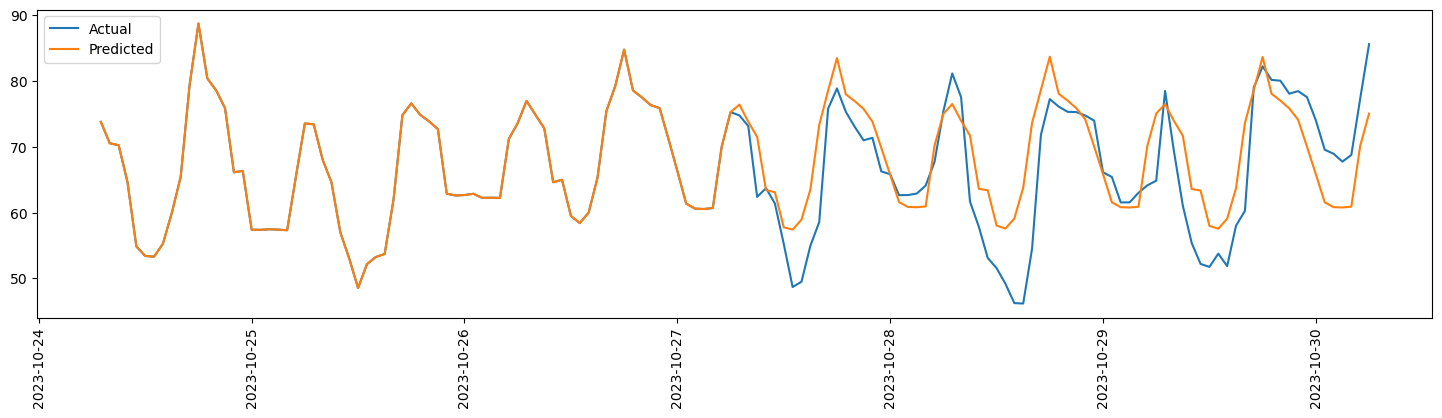

                                SARIMAX Results                                 
Dep. Variable:                NP-15 LMP   No. Observations:                30415
Model:             SARIMAX(1, 1, 0, 24)   Log Likelihood             -142944.966
Date:                  Wed, 16 Apr 2025   AIC                         285893.931
Time:                          14:30:27   BIC                         285910.575
Sample:                               0   HQIC                        285899.268
                                - 30415                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.S.L24      -0.1587      0.001   -273.028      0.000      -0.160      -0.158
sigma2       740.7804      0.561   1319.361      0.000     739.680     741.881
Ljung-Box (L1) (Q):               19

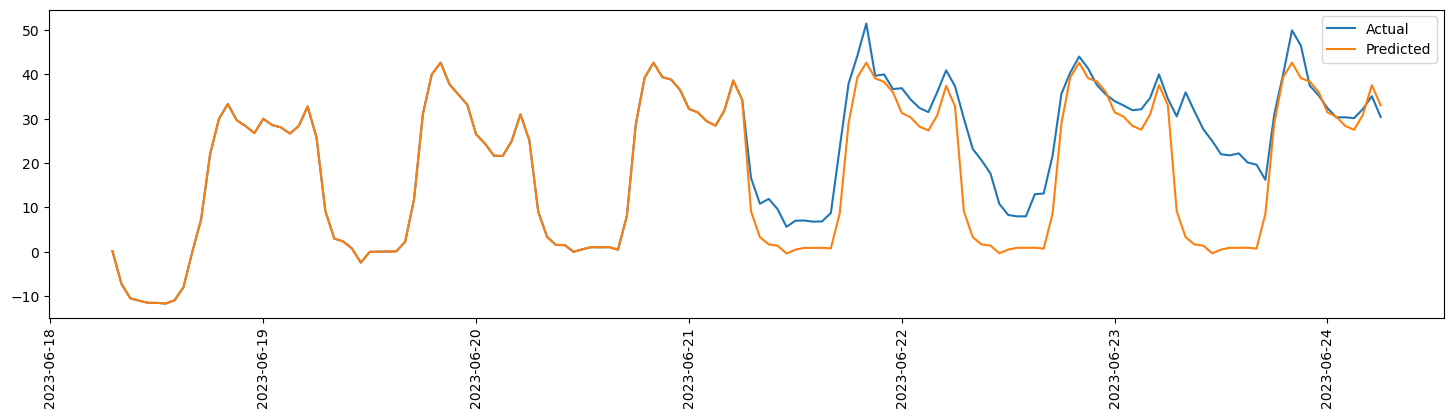

                                SARIMAX Results                                 
Dep. Variable:                NP-15 LMP   No. Observations:                30487
Model:             SARIMAX(1, 1, 0, 24)   Log Likelihood             -143251.268
Date:                  Wed, 16 Apr 2025   AIC                         286506.535
Time:                          14:31:17   BIC                         286523.184
Sample:                               0   HQIC                        286511.873
                                - 30487                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.S.L24      -0.1587      0.001   -273.530      0.000      -0.160      -0.158
sigma2       739.1323      0.559   1322.297      0.000     738.037     740.228
Ljung-Box (L1) (Q):               19

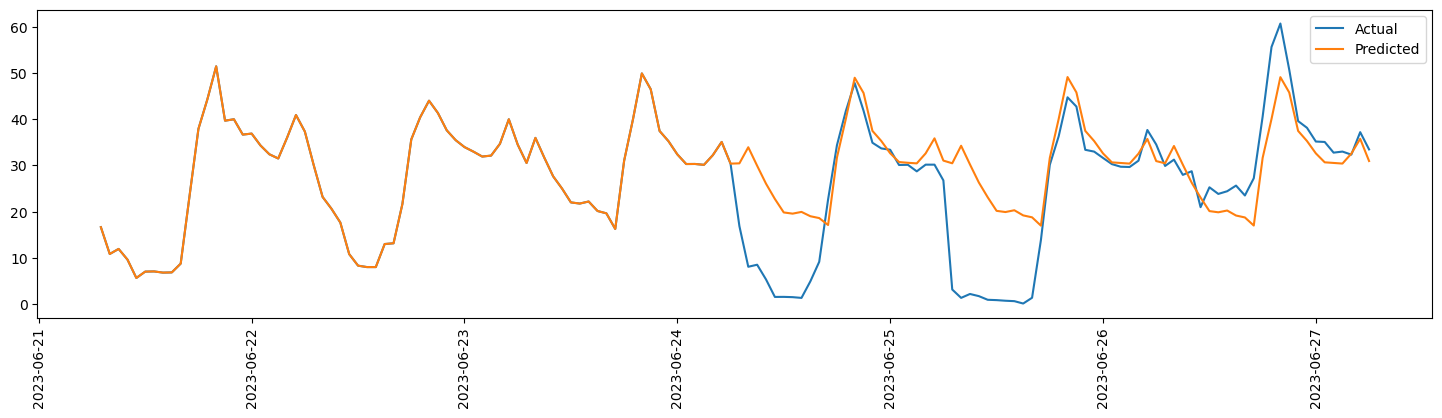

                                SARIMAX Results                                 
Dep. Variable:                NP-15 LMP   No. Observations:                30559
Model:             SARIMAX(1, 1, 0, 24)   Log Likelihood             -143562.897
Date:                  Wed, 16 Apr 2025   AIC                         287129.795
Time:                          14:32:11   BIC                         287146.448
Sample:                               0   HQIC                        287135.133
                                - 30559                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.S.L24      -0.1588      0.001   -274.205      0.000      -0.160      -0.158
sigma2       737.7545      0.557   1324.789      0.000     736.663     738.846
Ljung-Box (L1) (Q):               19

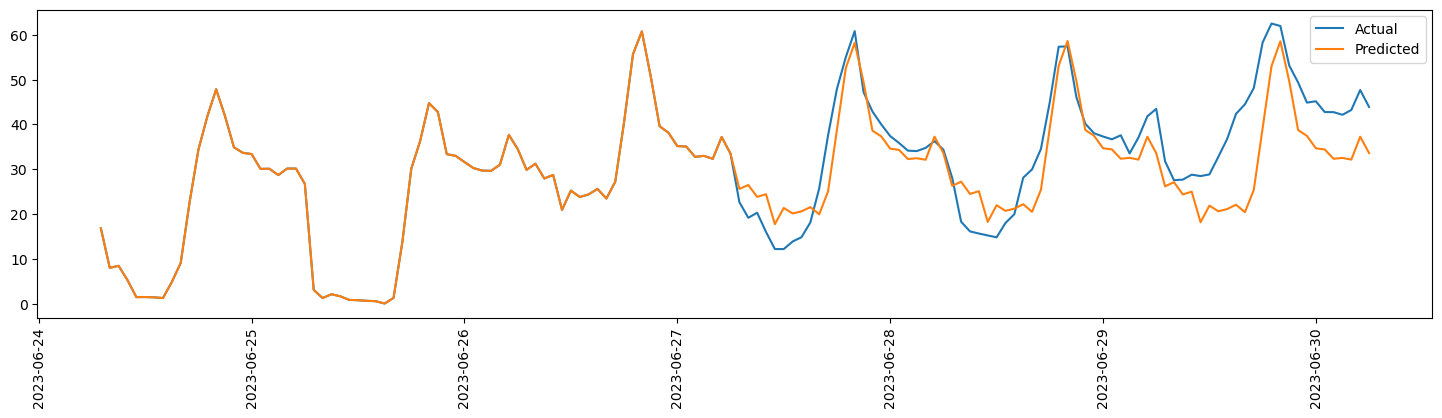

                                SARIMAX Results                                 
Dep. Variable:                NP-15 LMP   No. Observations:                28951
Model:             SARIMAX(1, 1, 0, 24)   Log Likelihood             -136656.872
Date:                  Wed, 16 Apr 2025   AIC                         273317.744
Time:                          14:33:10   BIC                         273334.289
Sample:                               0   HQIC                        273323.062
                                - 28951                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.S.L24      -0.1606      0.001   -264.559      0.000      -0.162      -0.159
sigma2       773.7368      0.612   1263.393      0.000     772.536     774.937
Ljung-Box (L1) (Q):               18

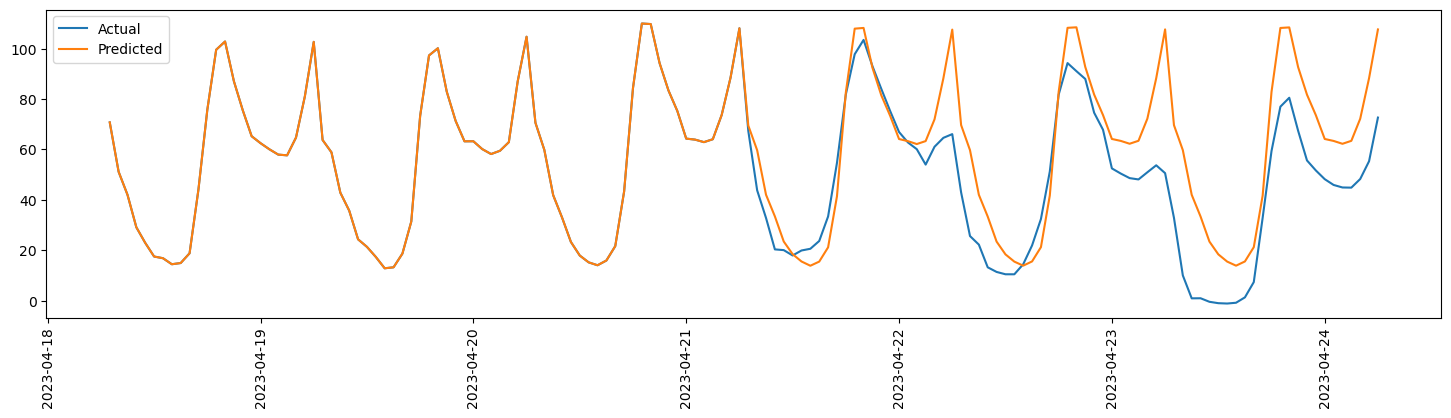

                                SARIMAX Results                                 
Dep. Variable:                NP-15 LMP   No. Observations:                29023
Model:             SARIMAX(1, 1, 0, 24)   Log Likelihood             -136970.853
Date:                  Wed, 16 Apr 2025   AIC                         273945.706
Time:                          14:34:09   BIC                         273962.256
Sample:                               0   HQIC                        273951.025
                                - 29023                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.S.L24      -0.1604      0.001   -264.736      0.000      -0.162      -0.159
sigma2       772.2553      0.610   1265.786      0.000     771.060     773.451
Ljung-Box (L1) (Q):               18

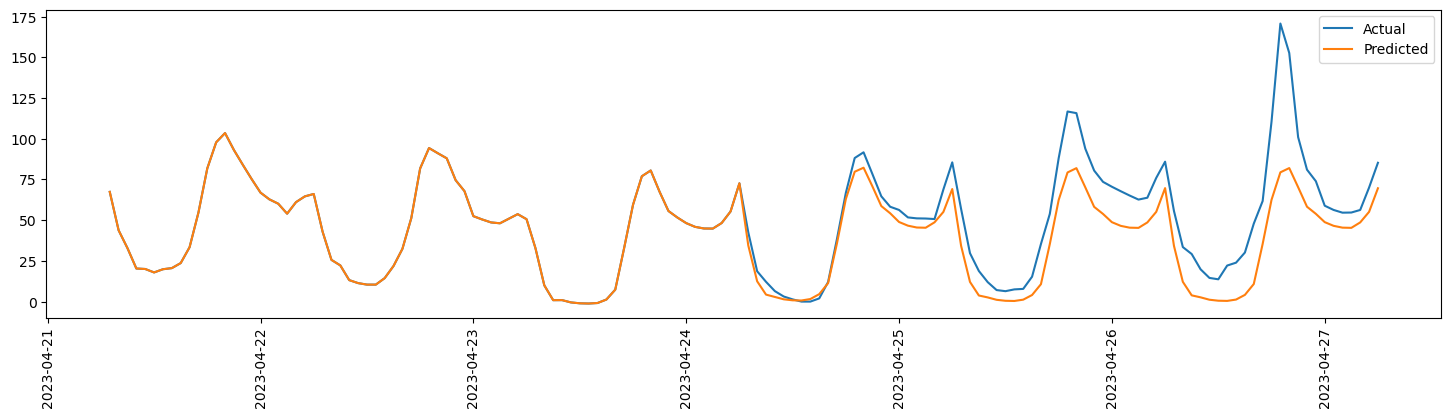

                                SARIMAX Results                                 
Dep. Variable:                NP-15 LMP   No. Observations:                29095
Model:             SARIMAX(1, 1, 0, 24)   Log Likelihood             -137285.852
Date:                  Wed, 16 Apr 2025   AIC                         274575.703
Time:                          14:35:17   BIC                         274592.258
Sample:                               0   HQIC                        274581.023
                                - 29095                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.S.L24      -0.1601      0.001   -264.770      0.000      -0.161      -0.159
sigma2       770.8383      0.608   1268.070      0.000     769.647     772.030
Ljung-Box (L1) (Q):               18

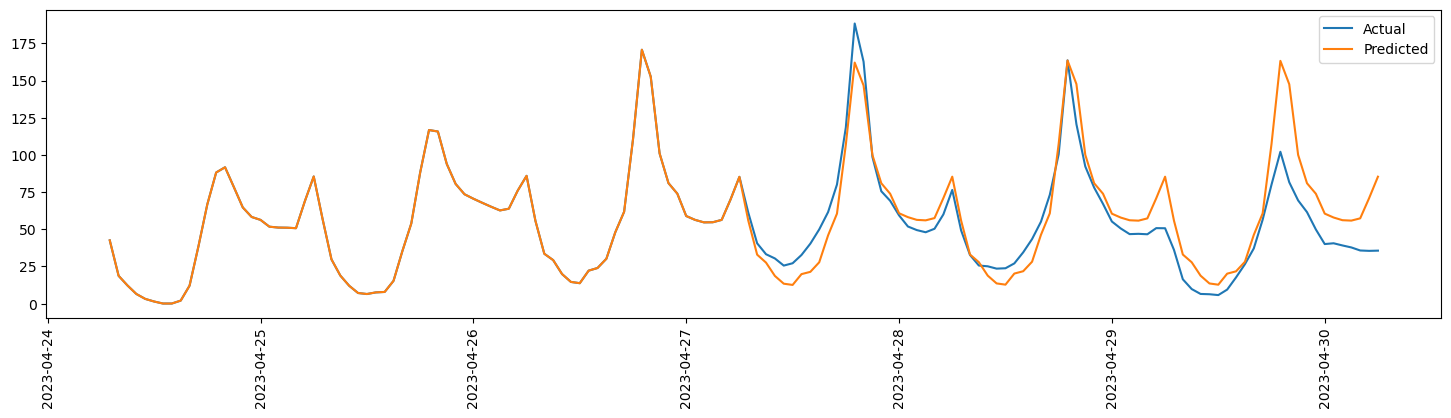

                                SARIMAX Results                                 
Dep. Variable:                NP-15 LMP   No. Observations:                27487
Model:             SARIMAX(1, 1, 0, 24)   Log Likelihood             -130098.016
Date:                  Wed, 16 Apr 2025   AIC                         260200.032
Time:                          14:36:14   BIC                         260216.474
Sample:                               0   HQIC                        260205.330
                                - 27487                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.S.L24      -0.1635      0.001   -262.194      0.000      -0.165      -0.162
sigma2       795.7049      0.647   1228.924      0.000     794.436     796.974
Ljung-Box (L1) (Q):               17

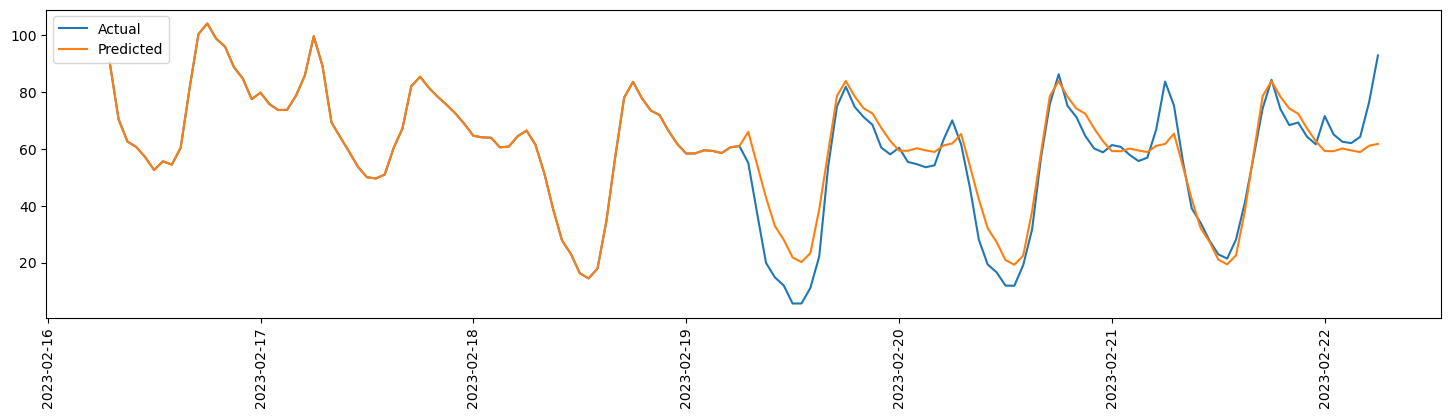

                                SARIMAX Results                                 
Dep. Variable:                NP-15 LMP   No. Observations:                27559
Model:             SARIMAX(1, 1, 0, 24)   Log Likelihood             -130407.817
Date:                  Wed, 16 Apr 2025   AIC                         260819.635
Time:                          14:37:19   BIC                         260836.081
Sample:                               0   HQIC                        260824.933
                                - 27559                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.S.L24      -0.1633      0.001   -262.444      0.000      -0.164      -0.162
sigma2       793.7992      0.644   1231.840      0.000     792.536     795.062
Ljung-Box (L1) (Q):               17

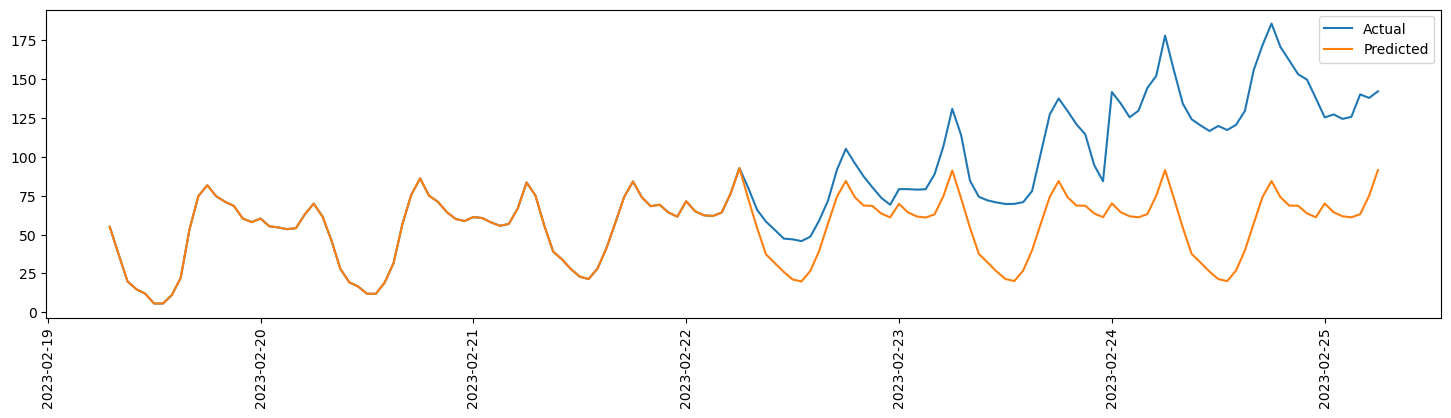

                                SARIMAX Results                                 
Dep. Variable:                NP-15 LMP   No. Observations:                27631
Model:             SARIMAX(1, 1, 0, 24)   Log Likelihood             -130772.926
Date:                  Wed, 16 Apr 2025   AIC                         261549.852
Time:                          14:38:20   BIC                         261566.304
Sample:                               0   HQIC                        261555.152
                                - 27631                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.S.L24      -0.1614      0.001   -258.942      0.000      -0.163      -0.160
sigma2       795.1050      0.647   1229.511      0.000     793.838     796.372
Ljung-Box (L1) (Q):               17

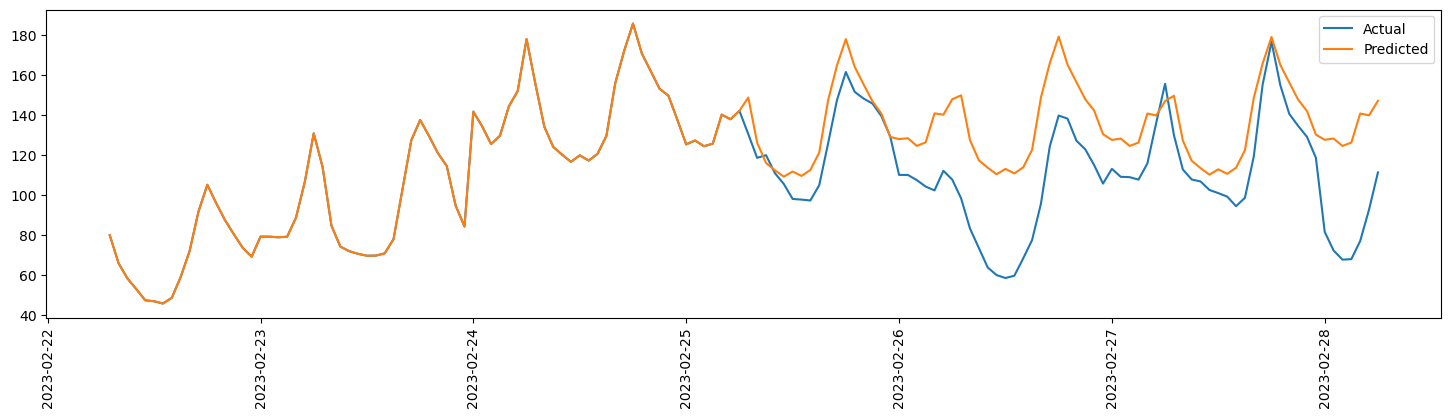

479.1926769952088


In [15]:
crossValidate(data_train_list, 3, 72, (1,1,0, 24), (0,0,0))

                                SARIMAX Results                                 
Dep. Variable:                NP-15 LMP   No. Observations:                34784
Model:             SARIMAX(0, 1, 0, 24)   Log Likelihood             -157109.892
Date:                  Wed, 16 Apr 2025   AIC                         314221.784
Time:                          14:39:00   BIC                         314230.240
Sample:                               0   HQIC                        314224.478
                                - 34784                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2       696.7183      0.448   1554.782      0.000     695.840     697.597
Ljung-Box (L1) (Q):               21817.21   Jarque-Bera (JB):         128829496.53
Prob(Q):                       

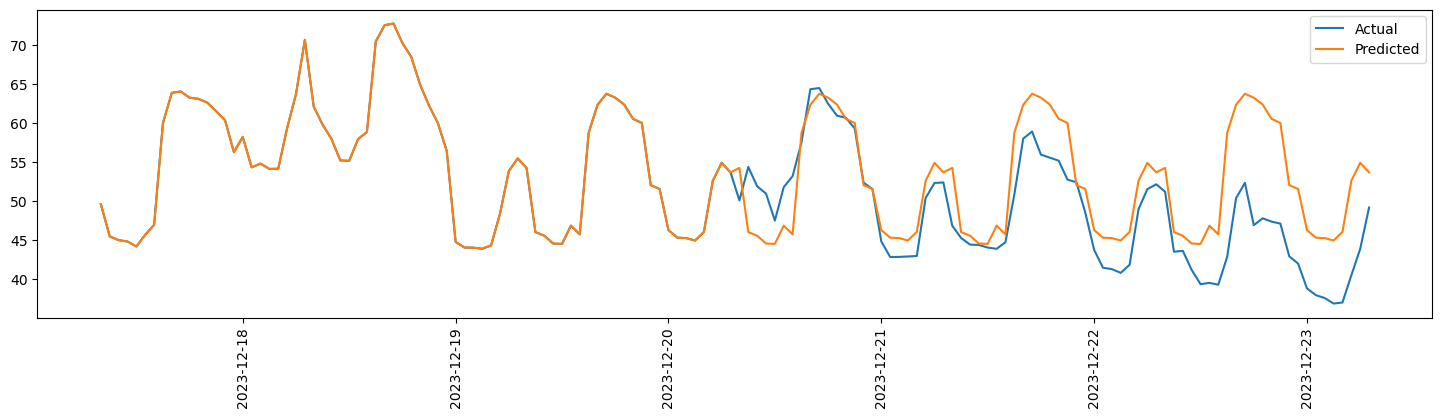

                                SARIMAX Results                                 
Dep. Variable:                NP-15 LMP   No. Observations:                34856
Model:             SARIMAX(0, 1, 0, 24)   Log Likelihood             -157412.980
Date:                  Wed, 16 Apr 2025   AIC                         314827.961
Time:                          14:39:04   BIC                         314836.419
Sample:                               0   HQIC                        314830.655
                                - 34856                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2       695.2755      0.446   1558.014      0.000     694.401     696.150
Ljung-Box (L1) (Q):               21862.59   Jarque-Bera (JB):         129594621.06
Prob(Q):                       

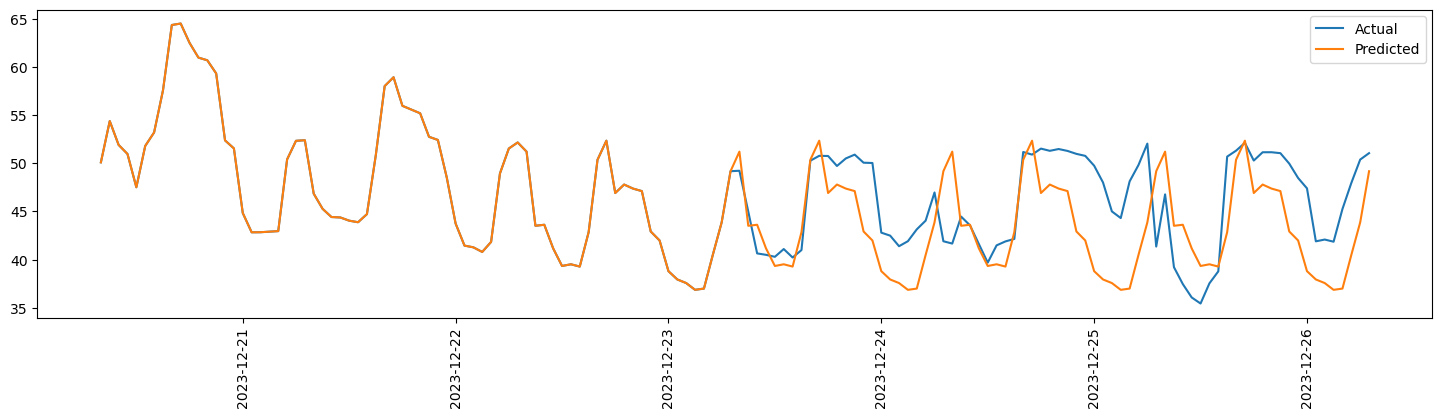

                                SARIMAX Results                                 
Dep. Variable:                NP-15 LMP   No. Observations:                34928
Model:             SARIMAX(0, 1, 0, 24)   Log Likelihood             -157715.456
Date:                  Wed, 16 Apr 2025   AIC                         315432.912
Time:                          14:39:07   BIC                         315441.372
Sample:                               0   HQIC                        315435.607
                                - 34928                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2       693.8164      0.444   1561.296      0.000     692.945     694.687
Ljung-Box (L1) (Q):               21907.12   Jarque-Bera (JB):         130382206.77
Prob(Q):                       

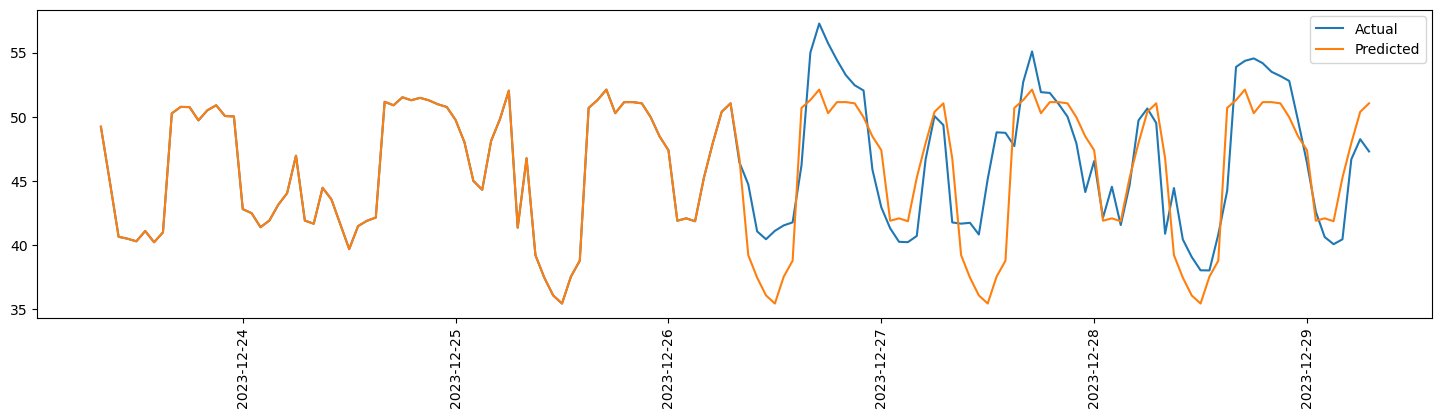

                                SARIMAX Results                                 
Dep. Variable:                NP-15 LMP   No. Observations:                33343
Model:             SARIMAX(0, 1, 0, 24)   Log Likelihood             -151049.953
Date:                  Wed, 16 Apr 2025   AIC                         302101.905
Time:                          14:39:09   BIC                         302110.319
Sample:                               0   HQIC                        302104.591
                                - 33343                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2       723.1835      0.483   1497.790      0.000     722.237     724.130
Ljung-Box (L1) (Q):               20880.03   Jarque-Bera (JB):         116147047.44
Prob(Q):                       

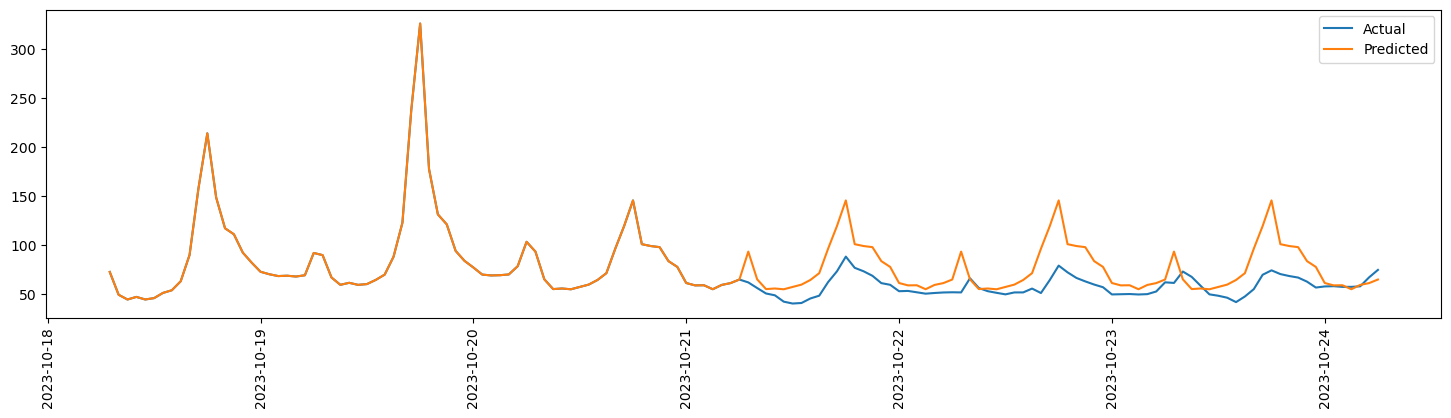

                                SARIMAX Results                                 
Dep. Variable:                NP-15 LMP   No. Observations:                33415
Model:             SARIMAX(0, 1, 0, 24)   Log Likelihood             -151363.640
Date:                  Wed, 16 Apr 2025   AIC                         302729.280
Time:                          14:39:12   BIC                         302737.696
Sample:                               0   HQIC                        302731.967
                                - 33415                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2       722.0360      0.481   1500.176      0.000     721.093     722.979
Ljung-Box (L1) (Q):               20929.47   Jarque-Bera (JB):         116594278.60
Prob(Q):                       

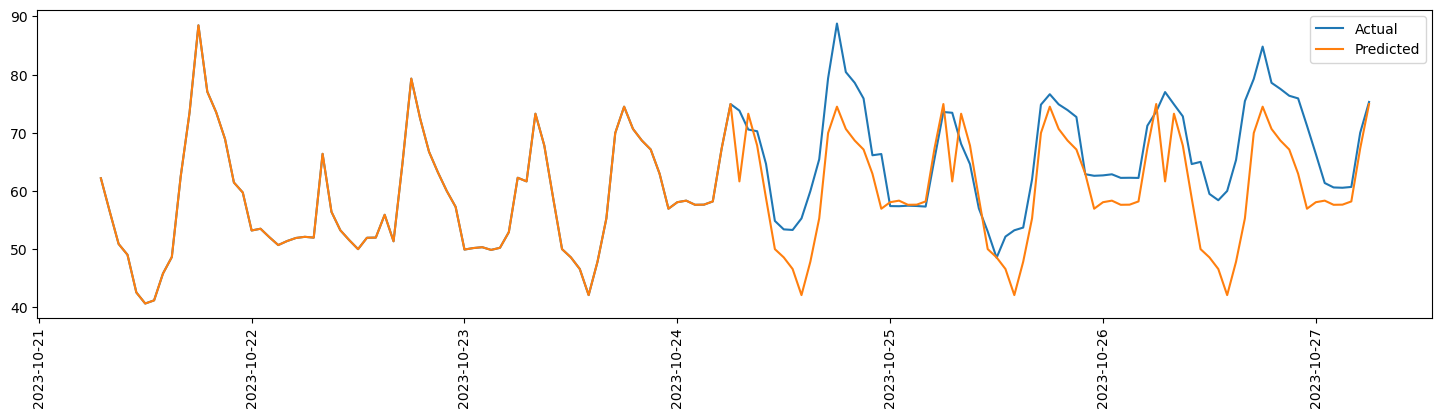

                                SARIMAX Results                                 
Dep. Variable:                NP-15 LMP   No. Observations:                33487
Model:             SARIMAX(0, 1, 0, 24)   Log Likelihood             -151668.958
Date:                  Wed, 16 Apr 2025   AIC                         303339.917
Time:                          14:39:15   BIC                         303348.335
Sample:                               0   HQIC                        303342.604
                                - 33487                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2       720.5206      0.479   1503.336      0.000     719.581     721.460
Ljung-Box (L1) (Q):               20974.90   Jarque-Bera (JB):         117291459.43
Prob(Q):                       

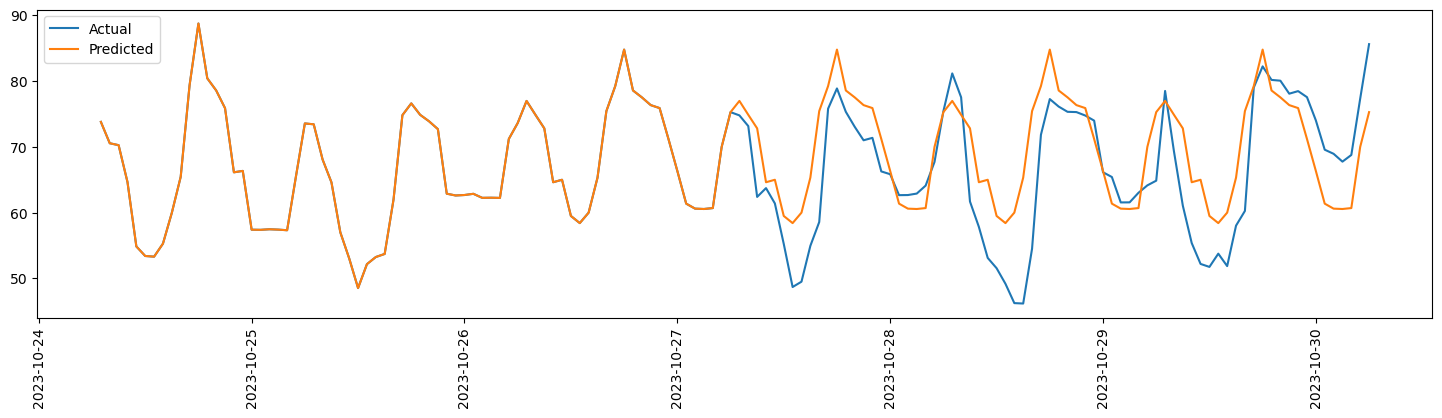

                                SARIMAX Results                                 
Dep. Variable:                NP-15 LMP   No. Observations:                30415
Model:             SARIMAX(0, 1, 0, 24)   Log Likelihood             -143331.327
Date:                  Wed, 16 Apr 2025   AIC                         286664.654
Time:                          14:39:18   BIC                         286672.976
Sample:                               0   HQIC                        286667.322
                                - 30415                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2       758.2203      0.531   1428.225      0.000     757.180     759.261
Ljung-Box (L1) (Q):               19043.85   Jarque-Bera (JB):          91439847.23
Prob(Q):                       

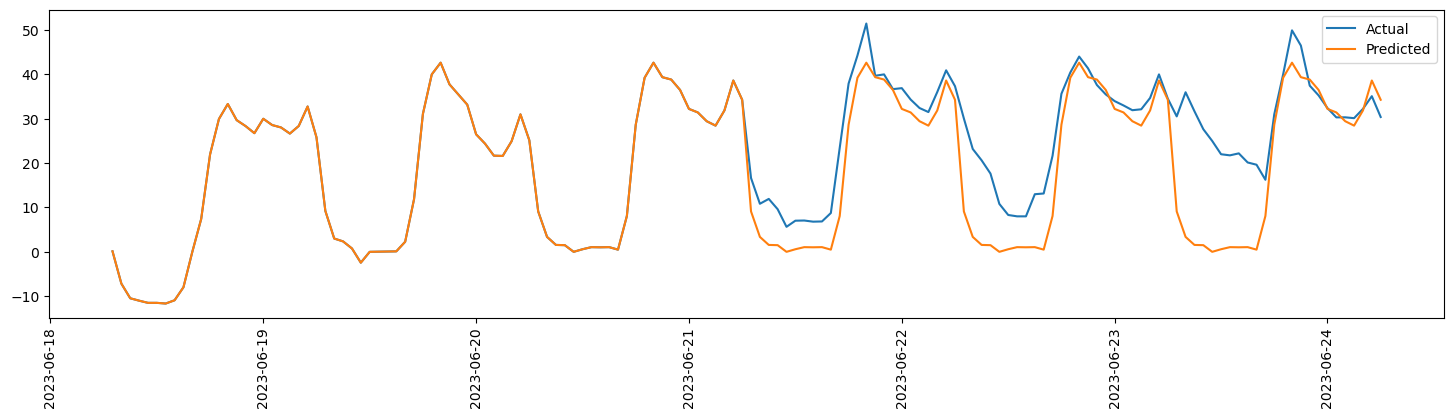

                                SARIMAX Results                                 
Dep. Variable:                NP-15 LMP   No. Observations:                30487
Model:             SARIMAX(0, 1, 0, 24)   Log Likelihood             -143638.239
Date:                  Wed, 16 Apr 2025   AIC                         287278.478
Time:                          14:39:20   BIC                         287286.803
Sample:                               0   HQIC                        287281.147
                                - 30487                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2       756.5245      0.529   1431.432      0.000     755.489     757.560
Ljung-Box (L1) (Q):               19089.28   Jarque-Bera (JB):          92046789.45
Prob(Q):                       

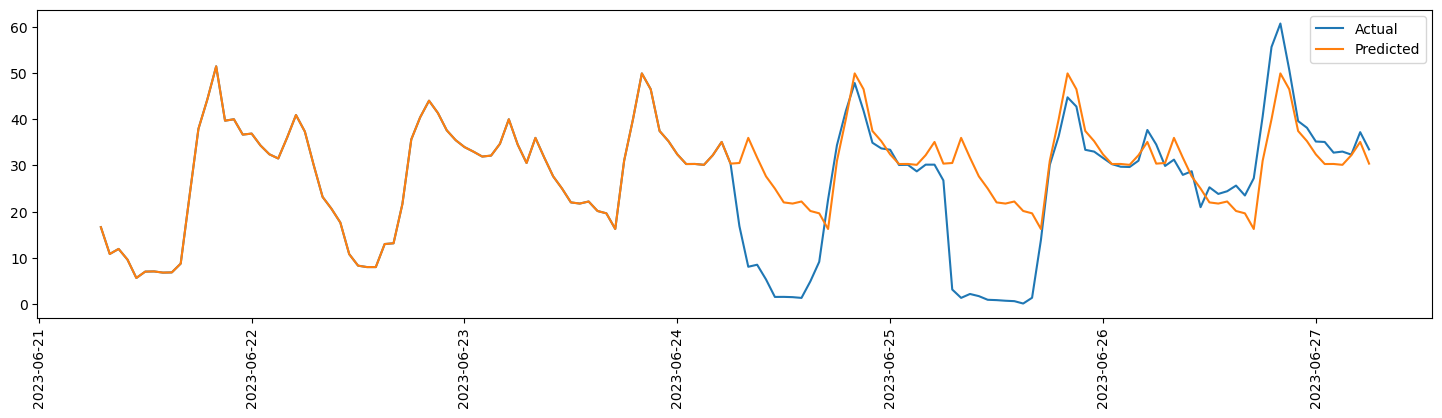

                                SARIMAX Results                                 
Dep. Variable:                NP-15 LMP   No. Observations:                30559
Model:             SARIMAX(0, 1, 0, 24)   Log Likelihood             -143951.126
Date:                  Wed, 16 Apr 2025   AIC                         287904.252
Time:                          14:39:22   BIC                         287912.579
Sample:                               0   HQIC                        287906.921
                                - 30559                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2       755.1371      0.527   1434.067      0.000     754.105     756.169
Ljung-Box (L1) (Q):               19137.96   Jarque-Bera (JB):          92506313.55
Prob(Q):                       

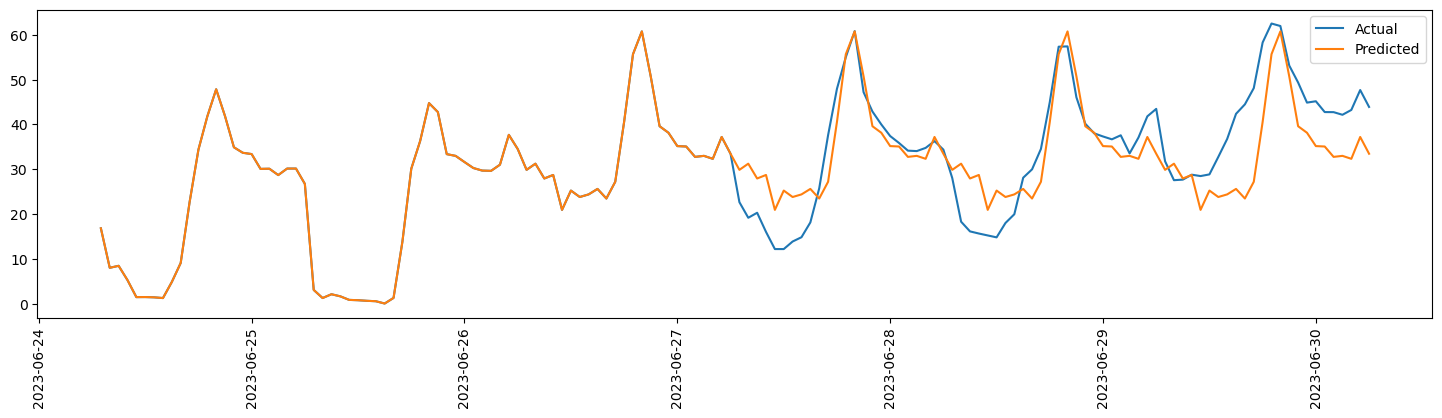

                                SARIMAX Results                                 
Dep. Variable:                NP-15 LMP   No. Observations:                28951
Model:             SARIMAX(0, 1, 0, 24)   Log Likelihood             -137033.385
Date:                  Wed, 16 Apr 2025   AIC                         274068.771
Time:                          14:39:24   BIC                         274077.043
Sample:                               0   HQIC                        274071.430
                                - 28951                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2       792.3036      0.580   1366.676      0.000     791.167     793.440
Ljung-Box (L1) (Q):               18101.12   Jarque-Bera (JB):          80574542.20
Prob(Q):                       

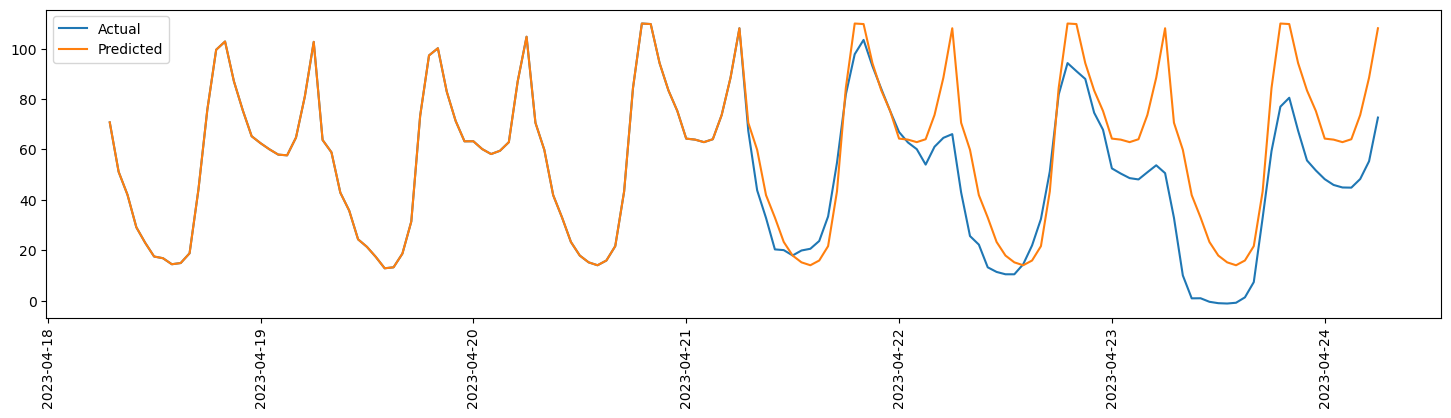

                                SARIMAX Results                                 
Dep. Variable:                NP-15 LMP   No. Observations:                29023
Model:             SARIMAX(0, 1, 0, 24)   Log Likelihood             -137347.335
Date:                  Wed, 16 Apr 2025   AIC                         274696.670
Time:                          14:39:27   BIC                         274704.945
Sample:                               0   HQIC                        274699.330
                                - 29023                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2       790.7405      0.577   1369.382      0.000     789.609     791.872
Ljung-Box (L1) (Q):               18147.56   Jarque-Bera (JB):          81007369.20
Prob(Q):                       

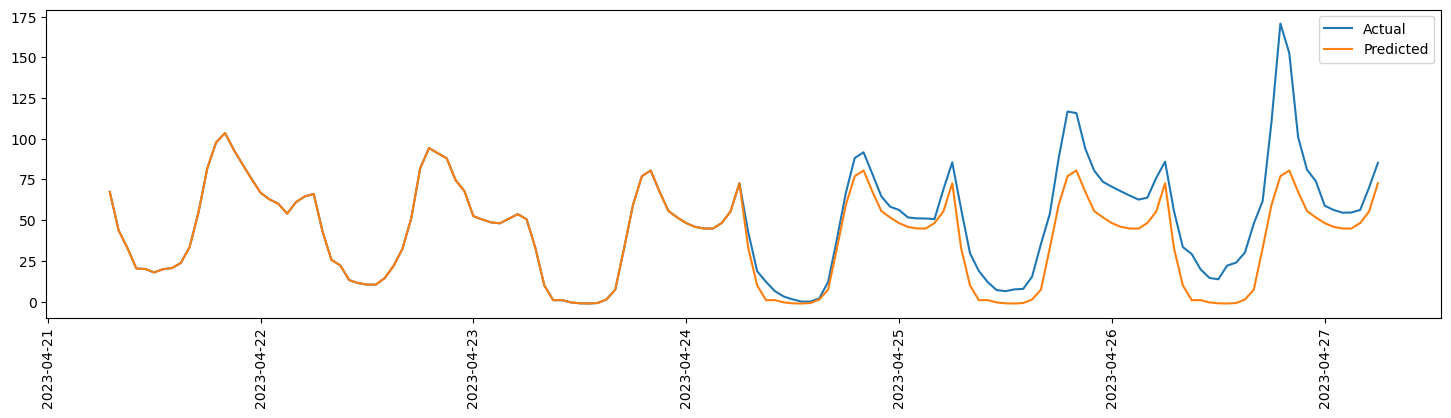

                                SARIMAX Results                                 
Dep. Variable:                NP-15 LMP   No. Observations:                29095
Model:             SARIMAX(0, 1, 0, 24)   Log Likelihood             -137662.019
Date:                  Wed, 16 Apr 2025   AIC                         275326.038
Time:                          14:39:29   BIC                         275334.315
Sample:                               0   HQIC                        275328.698
                                - 29095                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2       789.2283      0.575   1372.012      0.000     788.101     790.356
Ljung-Box (L1) (Q):               18194.93   Jarque-Bera (JB):          81431548.46
Prob(Q):                       

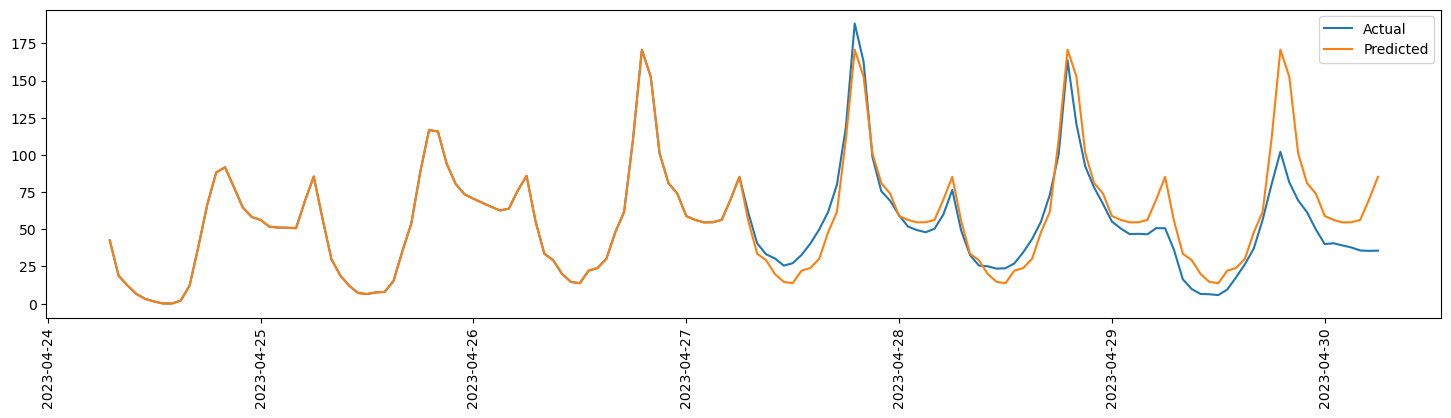

                                SARIMAX Results                                 
Dep. Variable:                NP-15 LMP   No. Observations:                27487
Model:             SARIMAX(0, 1, 0, 24)   Log Likelihood             -130468.637
Date:                  Wed, 16 Apr 2025   AIC                         260939.273
Time:                          14:39:31   BIC                         260947.494
Sample:                               0   HQIC                        260941.922
                                - 27487                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2       815.4849      0.614   1327.722      0.000     814.281     816.689
Ljung-Box (L1) (Q):               17054.97   Jarque-Bera (JB):          75651326.99
Prob(Q):                       

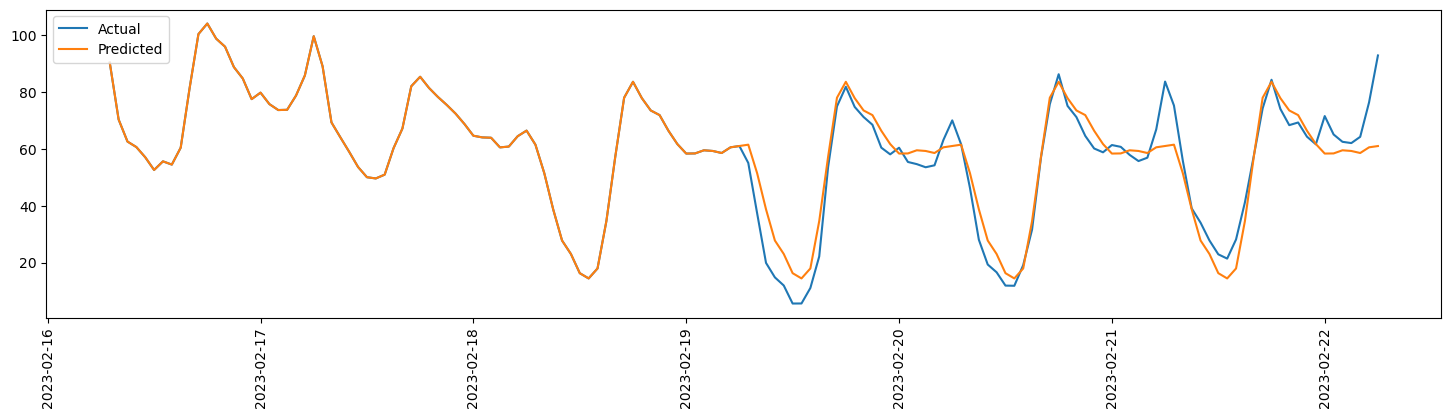

                                SARIMAX Results                                 
Dep. Variable:                NP-15 LMP   No. Observations:                27559
Model:             SARIMAX(0, 1, 0, 24)   Log Likelihood             -130778.493
Date:                  Wed, 16 Apr 2025   AIC                         261558.985
Time:                          14:39:33   BIC                         261567.209
Sample:                               0   HQIC                        261561.635
                                - 27559                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2       813.4856      0.611   1330.991      0.000     812.288     814.684
Ljung-Box (L1) (Q):               17100.30   Jarque-Bera (JB):          76199225.25
Prob(Q):                       

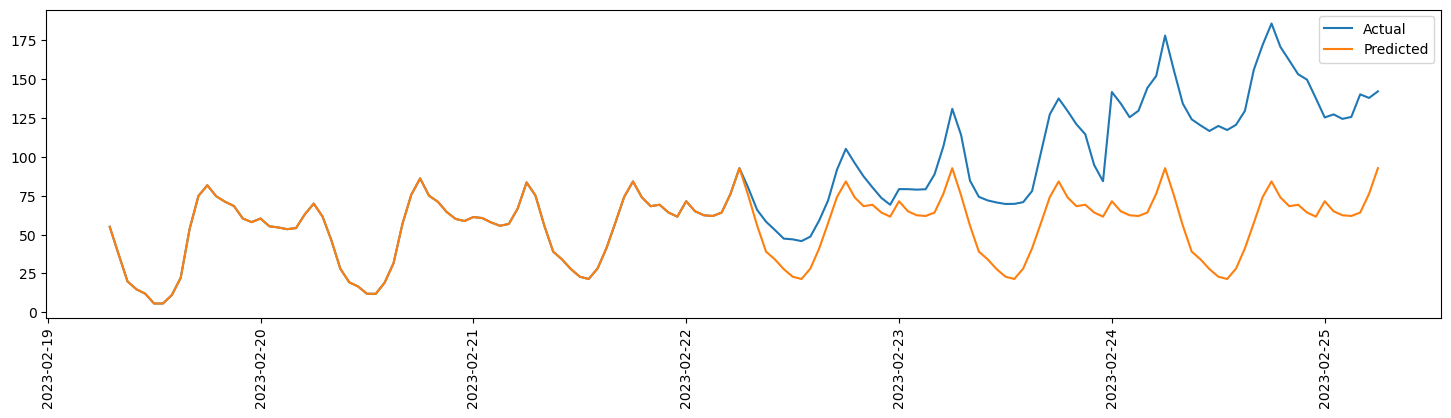

                                SARIMAX Results                                 
Dep. Variable:                NP-15 LMP   No. Observations:                27631
Model:             SARIMAX(0, 1, 0, 24)   Log Likelihood             -131135.628
Date:                  Wed, 16 Apr 2025   AIC                         262273.256
Time:                          14:39:35   BIC                         262281.482
Sample:                               0   HQIC                        262275.906
                                - 27631                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2       814.2985      0.612   1329.674      0.000     813.098     815.499
Ljung-Box (L1) (Q):               17167.57   Jarque-Bera (JB):          75706055.99
Prob(Q):                       

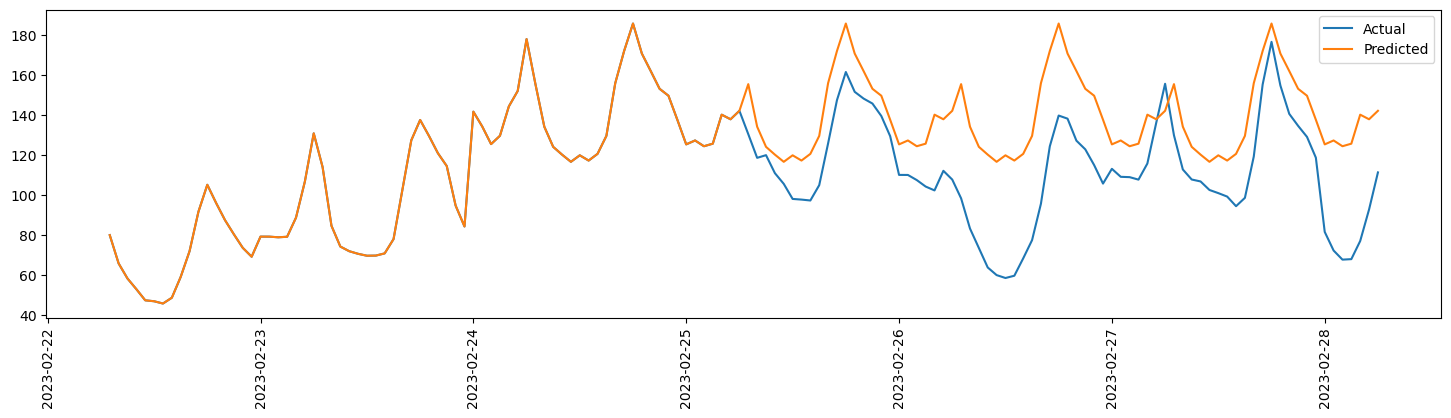

471.56389280776233


In [16]:
crossValidate(data_train_list, 3, 72, (0,1,0, 24), (0,0,0))